UPPGIFT: Grupp projekt i datarening och EDA 13.04.2026

Välj ett valfritt icke-renad dataset (runt 10 eller flera variabler, numeriska och kategoriska/ordinala), förberedd data för EDA (datarening).

Utför en EDA, inklusive statistiska summeringar, statistik med hypotes testning, visualiseringar. Bygg enkel linjär regression och utvärdera dess prestanda.

Frågor: Vad kan du säga om datasetet baserat på din EDA? Finns det några uppenbara mönster eller avvikelser?

Presentation: Beskriv datasetet, variabler. Hur ni renade data, vilka alternativ fanns, vilka problem ni hade med datasetet. Presentera resultat som databerättelse (runt 15 min). Gör en story.

# Dataöversikt

Översikt
Original dataset:

Dataset med bortfall:
Datatyper och struktur - original
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
Datatyper och struktur - med bortfall
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
-

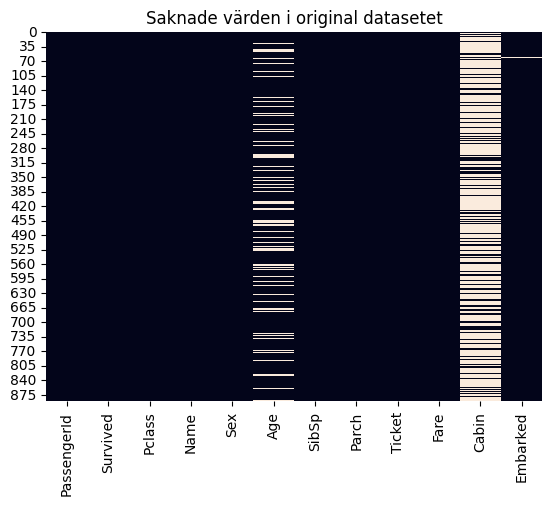

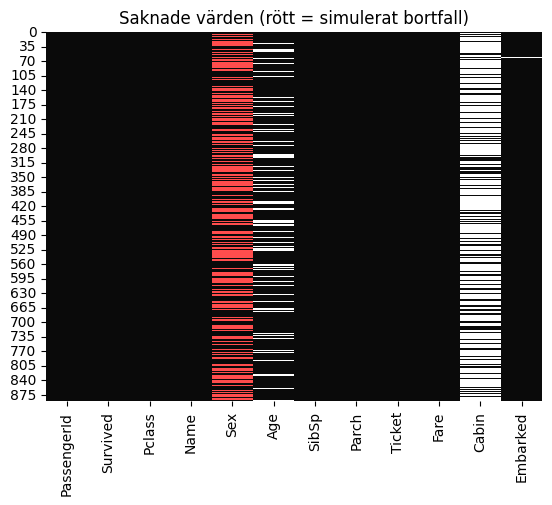

Dubbletter:  0


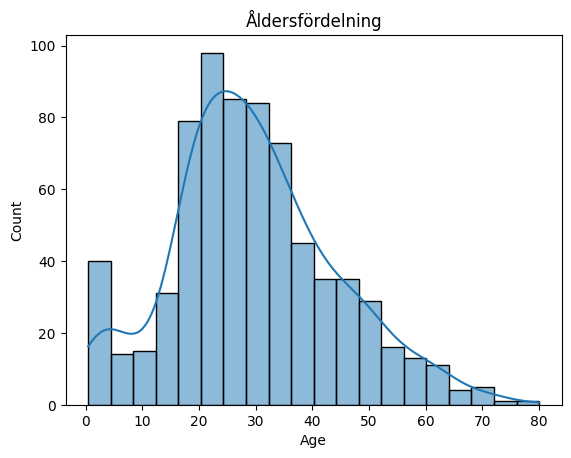


--- Embarked ---
Unika värden:
<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

Saknade värden: 2

Frekvens:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

--- Sex ---
Unika värden:
<StringArray>
['male', 'female', nan]
Length: 3, dtype: str

Saknade värden: 445

Frekvens:
Sex
NaN       445
male      297
female    149
Name: count, dtype: int64

Tomma strängar:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Felaktiga värden:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     

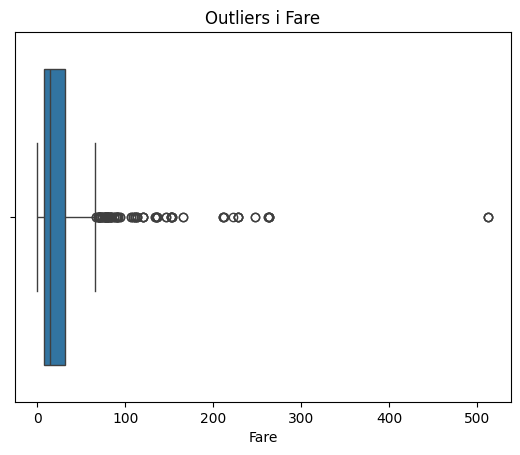

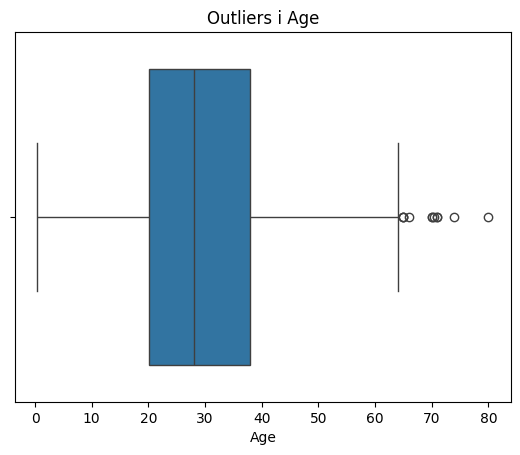


Datatyper:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [ ]:
# Importera bibliotek

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


# Ladda dataset
df_original = pd.read_csv("/Users/victoria/Documents/aikurs/02_datareningEDA/train.csv")
df_bortfall = pd.read_csv("/Users/victoria/Documents/aikurs/02_datareningEDA/train_bortfall.csv")

# OVERVIEW
print("Översikt")
print("Original dataset:")
df_original.head(10)
print("\nDataset med bortfall:")
df_bortfall.head(10)


# Datatypes and Structure
print("Datatyper och struktur - original")
df_original.info()
print("Datatyper och struktur - med bortfall")
df_bortfall.info()

# Missing values
print("Saknade värden - Original:")
print(df_original.isna().sum())

print("Saknade värden - Dataset med bortfall:")
print(df_bortfall.isna().sum())

# Visualisation of original and corrupted data
print("Visualisering av original data")
sns.heatmap(df_original.isna(), cbar=False)
plt.title("Saknade värden i original datasetet")
plt.show()


# Heatmap of corrupted data (in red)
orig_na = df_original.isna()
bortfall_na = df_bortfall.isna()

new_missing = bortfall_na & ~orig_na
visual = np.zeros(df_bortfall.shape)

visual[orig_na] = 1          # original missing → white
visual[new_missing] = 2      # new missing → red

cmap = ListedColormap(["#0a0a0a", "#ffffff", "#ff4d4d"])
# black = data, white = original NaN, red = new NaN

sns.heatmap(visual, cmap=cmap, cbar=False, xticklabels=df_bortfall.columns)
plt.title("Saknade värden (rött = simulerat bortfall)")
plt.show()

# DUBBLETTER
print("Dubbletter: ", df_bortfall.duplicated().sum())

# Ålder
sns.histplot(df_bortfall['Age'], kde=True)
plt.title("Åldersfördelning")
plt.show()

# INKONSEKVENTA FORMAT
def check_categorical(column):
    print(f"\n--- {column.name} ---")
    
    # Unique values
    print("Unika värden:")
    print(column.unique())
    
    # Missing values
    print("\nSaknade värden:", column.isna().sum())
    
    # Count values
    print("\nFrekvens:")
    print(column.value_counts(dropna=False))

check_categorical(df_bortfall['Embarked'])
check_categorical(df_bortfall['Sex'])

# TOMMA STRÄNGER
print("\nTomma strängar:")
print((df_bortfall == "").sum())

# FELAKTIGA VÄRDEN
print("\nFelaktiga värden:")

# Summary
print(df_bortfall.describe())

# Logical checks
print("\nNegativ ålder:", (df_bortfall['Age'] < 0).sum())
print("Negativ biljettpris:", (df_bortfall['Fare'] < 0).sum())


# OUTLIERS
sns.boxplot(x=df_bortfall['Fare'])
plt.title("Outliers i Fare")
plt.show()

sns.boxplot(x=df_bortfall['Age'])
plt.title("Outliers i Age")
plt.show()

# KONVERTERING AV KATEGORISKA VARIABLER
print("\nDatatyper:")
print(df_bortfall.dtypes)

# Datarening
dataset: Kaggle-datasetet Titanic (orensat) med 50 % bortfall av könsvariabeln

10+ variabler:

1. PassengerID (passengerareID) - int64 måste vara unique
2. Survived (överlevde) - int64
3. Pclass (biljettklass) - int64
4. Name (namn) - str
5. Sex (kön) - str
6. Age (ålder)  - float64 - float (not int) and missing values
7. SibSp (syskon och maka) - int64
8. Parch (barn eller föräldrar) - int64
9. Ticket (biljettnummer) - str
10. Fare (biljettpris) - float64
11. Cabin (hyttnummer) - str - många missing values
12. Embarked (ombordstigningshamn) - str - missing values

Ombordstigningshamn (Embarked): Kategorisk variabel med väldigt lite bortfall (2 värden, <1% saknade).
➡️ Vi ersätter med typvärde

Ålder (Age): Numerisk variabel med bortfall och snedfördelning.
➡️ Vi ersätter med median för att minska påverkan av extremvärden

Hyttnummer (Cabin): Mycket stort bortfall (~77% saknade), vilket gör det svårt att ersätta värden utan att skapa bias. Variabeln är kategorisk (textbaserad - sträng).
➡️ Vi markerar saknade värden som “Unknown” istället för att ta bort data

Kön (Sex): Kategorisk variabel med stort bortfall (~50% saknade). Att ta bort rader skulle kraftigt minska datasetet.
➡️ Vi ersätter med typvärde (mode). 
⭐ Alternativ: härleda från titlar i namn (t.ex. namnen som har “Mr.”, “Master.” eller “Rev.” →  male, och “Miss.”, “Mrs.” eller “Madame” → female)


Saknade värden efter rensning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Dubbletter: 0

--- Embarked ---
Unika värden:
<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

Saknade värden: 0

Frekvens:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

--- Sex ---
Unika värden:
<StringArray>
['male', 'female']
Length: 2, dtype: str

Saknade värden: 0

Frekvens:
Sex
male      742
female    149
Name: count, dtype: int64

Tomma strängar:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Felaktiga värden efter kontroll:
Negativ ålder: 0
Negativ fare: 0

Antal outliers (Fare/biljettpris): 116

Antal outliers (Age/Ålder): 66


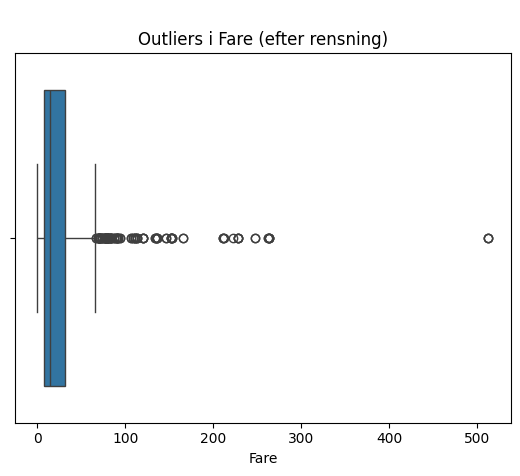

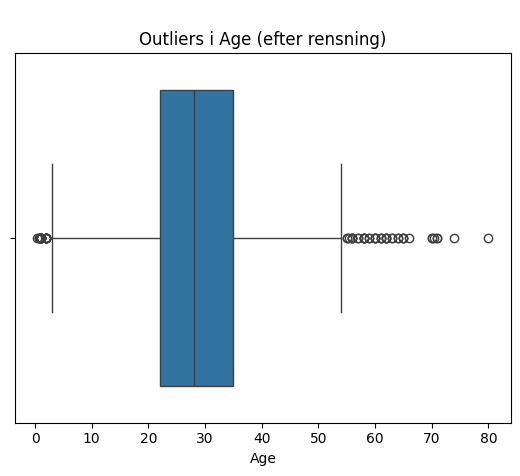


Konvertering av Kategoriska Variabler

Datatyper efter konvertering:
PassengerId       int64
Survived          int64
Pclass         category
Name                str
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Cabin          category
Embarked       category
dtype: object
ORIGINAL shape: (714, 10)
BORTFALL shape: (358, 10)
CLEAN shape: (891, 10)

Preview CLEAN model:
   PassengerId  Survived Pclass Sex   Age  SibSp  Parch     Fare  Embarked_Q  \
0            1         0      3   0  22.0      1      0   7.2500       False   
1            2         1      1   1  38.0      1      0  71.2833       False   
2            3         1      3   0  26.0      0      0   7.9250       False   
3            4         1      1   0  35.0      1      0  53.1000       False   
4            5         0      3   0  35.0      0      0   8.0500       False   

   Embarked_S  
0        True  
1       False  
2 

In [112]:
""" Datarening """

df_clean = df_bortfall.copy()

# Saknade värden
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Cabin'] = df_clean['Cabin'].fillna('Unknown')
df_clean['Sex'] = df_clean['Sex'].fillna(df_clean['Sex'].mode()[0])

        # härleda från titlar i namn?

print("\nSaknade värden efter rensning:")
print(df_clean.isna().sum())


# Dubbletter
df_clean = df_clean.drop_duplicates()
print("\nDubbletter:", df_clean.duplicated().sum())

# Inkonsekventa Format
check_categorical(df_clean['Embarked'])
check_categorical(df_clean['Sex'])

# Tomma strängar 
print("\nTomma strängar:")
print((df_clean == "").sum())

# Felaktiga värden

print("\nFelaktiga värden efter kontroll:")
print("Negativ ålder:", (df_clean['Age'] < 0).sum())
print("Negativ fare:", (df_clean['Fare'] < 0).sum())

# Outliers
Q1_F = df_clean['Fare'].quantile(0.25)
Q3_F = df_clean['Fare'].quantile(0.75)
IQR_F = Q3_F - Q1_F

outliers_Fare = df_clean[(df_clean['Fare'] < (Q1_F - 1.5 * IQR_F)) |
                    (df_clean['Fare'] > (Q3_F + 1.5 * IQR_F))]

print("\nAntal outliers (Fare/biljettpris):", len(outliers_Fare))

Q1_A = df_clean['Age'].quantile(0.25)
Q3_A = df_clean['Age'].quantile(0.75)
IQR_A = Q3_A - Q1_A

outliers_Age = df_clean[(df_clean['Age'] < (Q1_A - 1.5 * IQR_A)) |
                    (df_clean['Age'] > (Q3_A + 1.5 * IQR_A))]

print("\nAntal outliers (Age/Ålder):", len(outliers_Age))

sns.boxplot(x=df_clean['Fare'])
plt.title("\nOutliers i Fare (efter rensning)")
plt.show()

sns.boxplot(x=df_clean['Age'])
plt.title("\nOutliers i Age (efter rensning)")
plt.show()

# Konvertering av Kategoriska Variabler
print("\nKonvertering av Kategoriska Variabler")
# Dessa variabler representerar kategorier (kön, klass, hyttnummer och ombordstigningshamn)
df_clean['Sex'] = df_clean['Sex'].astype('category')
df_clean['Embarked'] = df_clean['Embarked'].astype('category')
df_clean['Cabin'] = df_clean['Cabin'].astype('category')
df_clean['Pclass'] = df_clean['Pclass'].astype('category')
print("\nDatatyper efter konvertering:")
print(df_clean.dtypes)


#ORIGINAL
df_original_model = df_original.copy()
df_original_model['Sex'] = df_original_model['Sex'].map({'male': 0, 'female': 1})
df_original_model = pd.get_dummies(df_original_model, columns=['Embarked'], drop_first=True)
df_original_model = df_original_model.drop(columns=['Name', 'Ticket', 'Cabin'])
df_original_model = df_original_model.dropna()

#BORTFALL
df_bortfall_model = df_bortfall.copy()
df_bortfall_model['Sex'] = df_bortfall_model['Sex'].map({'male': 0, 'female': 1})
df_bortfall_model = pd.get_dummies(df_bortfall_model, columns=['Embarked'], drop_first=True)
df_bortfall_model = df_bortfall_model.drop(columns=['Name', 'Ticket', 'Cabin'])
df_bortfall_model = df_bortfall_model.dropna()

#CLEAN
df_clean_model = df_clean.copy()
df_clean_model['Sex'] = df_clean_model['Sex'].map({'male': 0, 'female': 1})
df_clean_model = pd.get_dummies(df_clean_model, columns=['Embarked'], drop_first=True)
df_clean_model = df_clean_model.drop(columns=['Name', 'Ticket', 'Cabin'])
df_clean_model = df_clean_model.dropna()

print("ORIGINAL shape:", df_original_model.shape)
print("BORTFALL shape:", df_bortfall_model.shape)
print("CLEAN shape:", df_clean_model.shape)

print("\nPreview CLEAN model:")
print(df_clean_model.head())

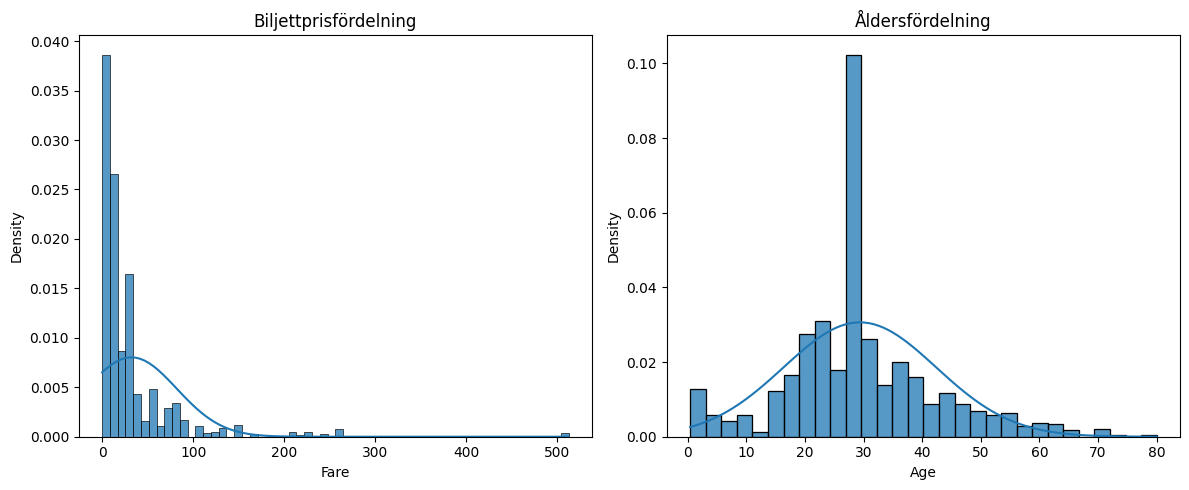

In [113]:
import numpy as np
import scipy.stats as stats

# Create figure with two plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- FARE ---
mean_fare = df_clean['Fare'].mean()
std_fare = df_clean['Fare'].std()
x_fare = np.linspace(df_clean['Fare'].min(), df_clean['Fare'].max(), 100)

sns.histplot(df_clean['Fare'], stat="density", ax=axes[0])
axes[0].plot(x_fare, stats.norm.pdf(x_fare, mean_fare, std_fare))
axes[0].set_title("Biljettprisfördelning")

# --- AGE ---
mean_age = df_clean['Age'].mean()
std_age = df_clean['Age'].std()
x_age = np.linspace(df_clean['Age'].min(), df_clean['Age'].max(), 100)

sns.histplot(df_clean['Age'], stat="density", ax=axes[1])
axes[1].plot(x_age, stats.norm.pdf(x_age, mean_age, std_age))
axes[1].set_title("Åldersfördelning")

plt.tight_layout()
plt.show()

# Skalning och Normalisering
Skalning och normalisering används för att sätta variabler på jämförbara skalor, särskilt när variabler har olika storleksordiningar. Skalning behövs inte här eftersom modellen fungerar utan det och resultaten blir lättare att tolka

# Min-Max Normalisering


In [114]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df_clean.copy()

df_scaled[['Age', 'Fare']] = scaler.fit_transform(df_scaled[['Age', 'Fare']])

print(df_scaled[['Age', 'Fare']].head())

comparison = pd.concat(
    [df_clean[['Age', 'Fare']].head(), df_scaled[['Age', 'Fare']].head()],
    axis=1,
    keys=['Original', 'Skalad']
)

print("\n", comparison)

        Age      Fare
0  0.271174  0.014151
1  0.472229  0.139136
2  0.321438  0.015469
3  0.434531  0.103644
4  0.434531  0.015713

   Original             Skalad          
       Age     Fare       Age      Fare
0     22.0   7.2500  0.271174  0.014151
1     38.0  71.2833  0.472229  0.139136
2     26.0   7.9250  0.321438  0.015469
3     35.0  53.1000  0.434531  0.103644
4     35.0   8.0500  0.434531  0.015713


# EDA (Exploratory Data Analysis)
## Statistika summeringar

In [115]:
print("\nFördelning av kön i dataseten:")

sex_compare = pd.DataFrame({
    "Original": df_original['Sex'].value_counts(),
    "Bortfall": df_bortfall['Sex'].value_counts(),
    "Clean": df_clean['Sex'].value_counts()
})

print("\n", sex_compare)

print("\nÖverlevnad per kön - original")
print(df_original.groupby('Sex')['Survived'].mean())

print("\nÖverlevnad per kön - bortfall")
print(df_bortfall.groupby('Sex')['Survived'].mean())

print("\nÖverlevnad per kön - rensad data")
print(df_clean.groupby('Sex')['Survived'].mean())



Fördelning av kön i dataseten:

         Original  Bortfall  Clean
Sex                              
male         577       297    742
female       314       149    149

Överlevnad per kön - original
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Överlevnad per kön - bortfall
Sex
female    0.724832
male      0.185185
Name: Survived, dtype: float64

Överlevnad per kön - rensad data
Sex
female    0.724832
male      0.315364
Name: Survived, dtype: float64


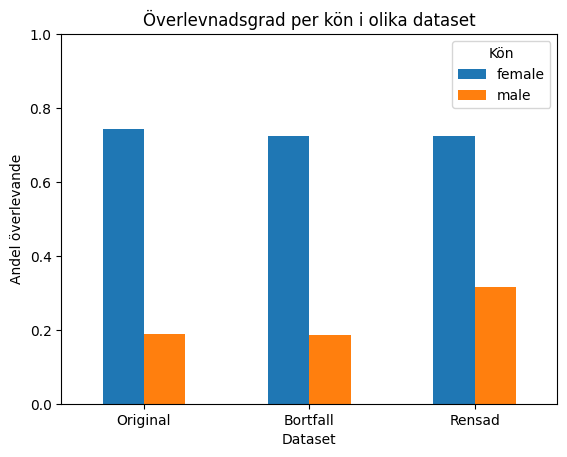

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


survival_compare = pd.DataFrame({
    "Original": df_original.groupby('Sex')['Survived'].mean(),
    "Bortfall": df_bortfall.groupby('Sex')['Survived'].mean(),
    "Rensad": df_clean.groupby('Sex')['Survived'].mean()
})

survival_compare.T.plot(kind='bar')

plt.title("Överlevnadsgrad per kön i olika dataset")
plt.ylabel("Andel överlevande")
plt.xlabel("Dataset")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(title="Kön")

plt.show()

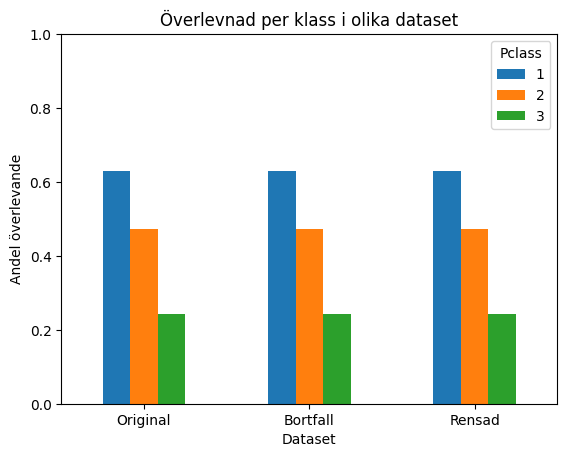

In [117]:
pclass_compare = pd.DataFrame({
    "Original": df_original.groupby('Pclass')['Survived'].mean(),
    "Bortfall": df_bortfall.groupby('Pclass')['Survived'].mean(),
    "Rensad": df_clean.groupby('Pclass')['Survived'].mean()
})

pclass_compare.T.plot(kind='bar')

plt.title("Överlevnad per klass i olika dataset")
plt.ylabel("Andel överlevande")
plt.xlabel("Dataset")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

Överlevnad per klass är oförändrad. Bortfall i kön påverkar främst analyser som rör kön.

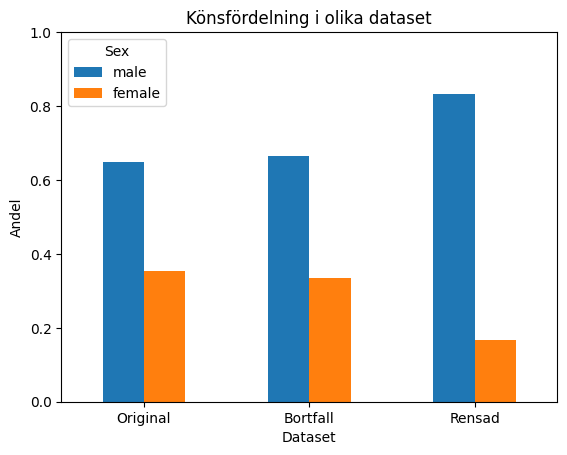

In [118]:
sex_compare_norm = pd.DataFrame({
    "Original": df_original['Sex'].value_counts(normalize=True),
    "Bortfall": df_bortfall['Sex'].value_counts(normalize=True),
    "Rensad": df_clean['Sex'].value_counts(normalize=True)
})

sex_compare_norm.T.plot(kind='bar')

plt.title("Könsfördelning i olika dataset")
plt.ylabel("Andel")
plt.xlabel("Dataset")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

In [119]:
print("Original:", df_original['Survived'].mean())
print("Bortfall:", df_bortfall['Survived'].mean())
print("Rensad:", df_clean['Survived'].mean())

Original: 0.3838383838383838
Bortfall: 0.3838383838383838
Rensad: 0.3838383838383838


# Linear Regression

In [120]:
# PREPARATION

# Original

df_original_model = df_original.copy()

# encode Sex
df_original_model['Sex'] = df_original_model['Sex'].map({'male': 0, 'female': 1})

# drop irrelevant columns
df_original_model = df_original_model.drop(columns=['Name', 'Ticket', 'Cabin'])

# encode Embarked
df_original_model = pd.get_dummies(df_original_model, columns=['Embarked'], drop_first=True)

# drop remaining NA
df_original_model = df_original_model.dropna()


# Bortfall
df_bortfall_model = df_bortfall.copy()

# encode Sex
df_bortfall_model['Sex'] = df_bortfall_model['Sex'].map({'male': 0, 'female': 1})

# drop irrelevant columns
df_bortfall_model = df_bortfall_model.drop(columns=['Name', 'Ticket', 'Cabin'])

# encode Embarked
df_bortfall_model = pd.get_dummies(df_bortfall_model, columns=['Embarked'], drop_first=True)

# drop remaining NA
df_bortfall_model = df_bortfall_model.dropna()


# Clean
df_clean_model = df_clean.copy()

# encode Sex
df_clean_model['Sex'] = df_clean_model['Sex'].map({'male': 0, 'female': 1})

# drop irrelevant columns
df_clean_model = df_clean_model.drop(columns=['Name', 'Ticket', 'Cabin'])

# encode Embarked
df_clean_model = pd.get_dummies(df_clean_model, columns=['Embarked'], drop_first=True)

# drop remaining NA
df_clean_model = df_clean_model.dropna()


# RUN
print(df_original_model.shape)
print(df_bortfall_model.shape)
print(df_clean_model.shape)

(714, 10)
(358, 10)
(891, 10)


Resultatet visar en tydlig trade-off: att ta bort saknade värden minskar datamängden kraftigt, medan imputering bevarar datan men riskerar att snedvrida analysen.

In [121]:
# REGRESSION

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def run_model(df):
    X = df[['Pclass', 'Sex', 'Age', 'Fare']]
    y = df['Survived']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    return r2_score(y_test, y_pred), mean_squared_error(y_test, y_pred)

# RUN

r2_orig, mse_orig = run_model(df_original_model)
r2_bort, mse_bort = run_model(df_bortfall_model)
r2_clean, mse_clean = run_model(df_clean_model)

print("Original:", r2_orig, mse_orig)
print("Bortfall:", r2_bort, mse_bort)
print("Rensad:", r2_clean, mse_clean)

Original: 0.28324455747693156 0.17076788674127777
Bortfall: 0.36123274880109557 0.14194827804420102
Rensad: 0.16533945342105694 0.20240668040692825


    Dataset        R2       MSE
0  Original  0.283245  0.170768
1  Bortfall  0.361233  0.141948
2    Rensad  0.165339  0.202407


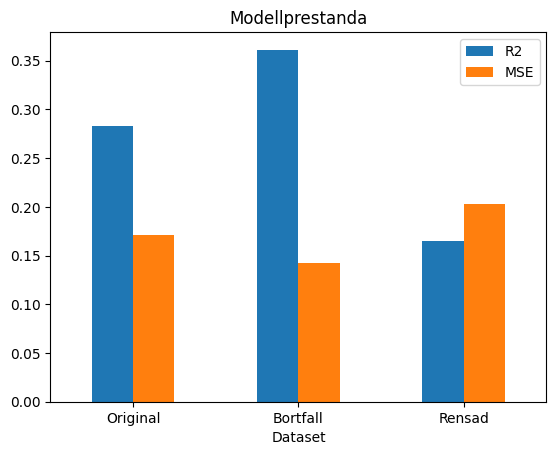

In [122]:
import pandas as pd

results = pd.DataFrame({
    "Dataset": ["Original", "Bortfall", "Rensad"],
    "R2": [r2_orig, r2_bort, r2_clean],
    "MSE": [mse_orig, mse_bort, mse_clean]
})

print(results)

results.set_index("Dataset").plot(kind='bar')

plt.title("Modellprestanda")
plt.xticks(rotation=0)

plt.show()

Här ser vi modellens prestanda för de tre dataseten, mätt med R² och MSE.
Originaldatan ligger på en stabil nivå.
Bortfallsdatan ser ut att prestera bättre, med högre R² och lägre MSE, men den innehåller bara hälften av observationerna och är därför mindre tillförlitlig.
Den rensade datan, där vi har ersatt saknade värden med typvärde, har sämst prestanda.
 R² är lägre och MSE högre, vilket visar att modellen gör sämre prediktioner.
Detta tyder på att imputeringen har snedvridit sambanden i datan.

# Slutsatser

Resultaten visar att saknade värden i en viktig variabel påverkar både analysen och modellprestanda, beroende på hur de hanteras.
Att ta bort data kan ge skenbart bättre resultat, men minskar datamängden och därmed generaliserbarheten.
Imputering bevarar datamängden men kan snedvrida sambanden i datan, vilket leder till sämre modellprestanda.
Det viktigaste är att saknade värden inte bara påverkar mängden data, utan även relationerna mellan variabler — vilket är avgörande för både analys och modellering.
